# SIR Outbreak Size (Kermack–McKendrick)

## Theory

Kermack and McKendrick (1927) showed that in a closed SIR model the final fraction
of susceptibles $s_\infty = S(\infty)/N$ satisfies the **final-size equation**:

$$s_\infty = e^{-R_0\,(1 - s_\infty)}$$

where $R_0 = \beta / \gamma$.  The **attack rate** (fraction ever infected) is:

$$\text{AR} = 1 - s_\infty$$

Key properties:
* $R_0 \leq 1$: no epidemic, AR ≈ 0.
* $R_0 > 1$: a major outbreak occurs; AR rises steeply with R₀.

An epidemic occurs only when $R_0 \cdot S(0)/N > 1$ (the **epidemic threshold**).

**Goal:** Compare the theoretical attack rate with the simulated final attack rate
across a range of R₀ values, and show the full S/I/R time series for R₀ = 3.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
import laser.cohorts.SIR as SIR

In [2]:
def solve_final_size(R0: float, s0: float = 1.0) -> float:
    """Return the expected attack rate for a given R0 and initial susceptible fraction.

    Solves the Kermack-McKendrick final-size equation
        s_inf = exp(-R0 * (1 - s_inf))
    for s_inf using Brent's method, then returns 1 - s_inf.

    Args:
        R0:  Basic reproduction number.
        s0:  Initial susceptible fraction (default 1.0 ≈ fully naive population).

    Returns:
        Attack rate AR = 1 - s_inf in [0, 1].
    """
    if R0 <= 1.0:
        return 0.0   # sub-threshold: no epidemic

    # f(s) = 0 at the non-trivial root  (s < s0)
    f = lambda s: s - np.exp(-R0 * (s0 - s))

    # Root lies in (0, s0); use a tiny lower bound to avoid the trivial root
    s_inf = brentq(f, 1e-9, s0 - 1e-9)
    return 1.0 - s_inf

In [3]:
# --- Sweep over R0 values ---
N      = 50_000
I0     = 10
nticks = 300
gamma  = 0.1      # recovery rate (per day); R0 = beta / gamma

R0_values = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

theoretical_AR = []
simulated_AR   = []

for R0 in R0_values:
    beta_val = R0 * gamma

    scenario = grid(M=1, N=1)
    scenario["S"] = N - I0
    scenario["I"] = I0
    scenario["R"] = 0

    params = PropertySet({"nticks": nticks, "beta": beta_val, "r_recovery": gamma})
    model  = Model(scenario, params)

    betas        = ValuesMap.from_scalar(beta_val, nticks, len(scenario))
    r_recoveries = ValuesMap.from_scalar(gamma,    nticks, len(scenario))

    model.components = [
        SIR.Susceptible(model),
        SIR.Infectious(model,  r_recovery=r_recoveries),
        SIR.Recovered(model),
        SIR.Transmission(model, beta=betas),
    ]
    model.run()

    # Attack rate = everyone who was ever infected = I_final + R_final
    I_final = model.states.I[-1, 0]
    R_final = model.states.R[-1, 0]
    sim_AR  = (I_final + R_final) / N

    s0 = (N - I0) / N
    th_AR = solve_final_size(R0, s0=s0)

    theoretical_AR.append(th_AR)
    simulated_AR.append(sim_AR)
    print(f"R₀ = {R0:.1f}  |  theory AR = {th_AR:.3f}  |  sim AR = {sim_AR:.3f}")

R₀ = 0.5  |  theory AR = 0.000  |  sim AR = 0.000
R₀ = 1.0  |  theory AR = 0.000  |  sim AR = 0.000


ValueError: f(a) and f(b) must have different signs

ValueError: 'c' argument has 6 elements, which is inconsistent with 'x' and 'y' with size 2.

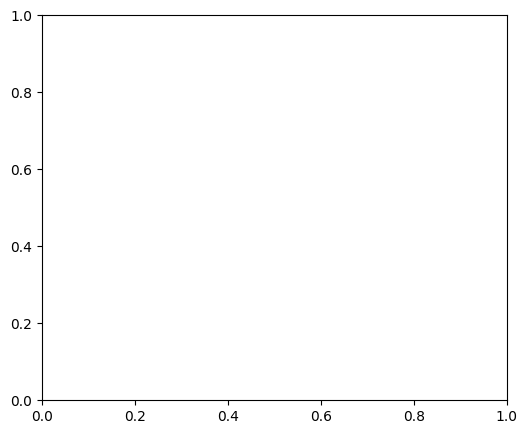

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(theoretical_AR, simulated_AR, s=80, zorder=3,
           c=R0_values, cmap="plasma", label="(theory, sim) pairs")

# Annotate each point with its R0
for th, sim, R0 in zip(theoretical_AR, simulated_AR, R0_values):
    ax.annotate(f"R₀={R0}", (th, sim), textcoords="offset points",
                xytext=(6, 3), fontsize=8)

# y = x reference line
lim = max(max(theoretical_AR), max(simulated_AR)) * 1.05
ax.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="y = x (perfect agreement)")

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Theoretical attack rate")
ax.set_ylabel("Simulated attack rate")
ax.set_title("Kermack–McKendrick final-size: theory vs. simulation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

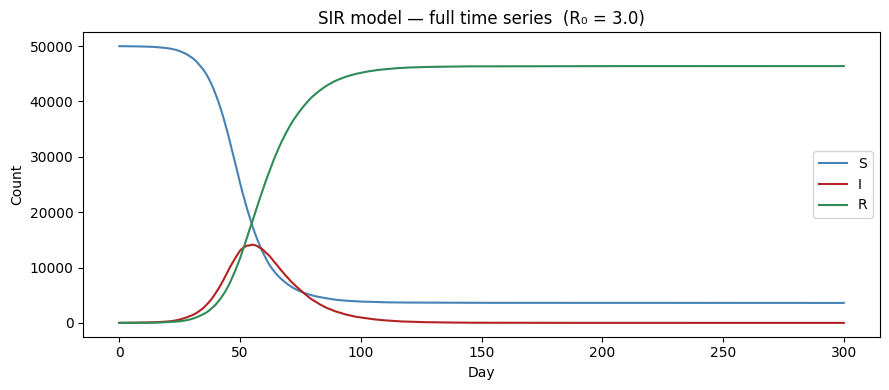

Final attack rate (simulated): 0.928


ValueError: f(a) and f(b) must have different signs

In [5]:
# --- Full SIR time series for R0 = 3 ---
R0_demo  = 3.0
beta_demo = R0_demo * gamma

scenario_demo = grid(M=1, N=1)
scenario_demo["S"] = N - I0
scenario_demo["I"] = I0
scenario_demo["R"] = 0

params_demo = PropertySet({"nticks": nticks, "beta": beta_demo, "r_recovery": gamma})
model_demo  = Model(scenario_demo, params_demo)

betas_demo       = ValuesMap.from_scalar(beta_demo, nticks, len(scenario_demo))
r_recoveries_demo = ValuesMap.from_scalar(gamma,    nticks, len(scenario_demo))

model_demo.components = [
    SIR.Susceptible(model_demo),
    SIR.Infectious(model_demo,  r_recovery=r_recoveries_demo),
    SIR.Recovered(model_demo),
    SIR.Transmission(model_demo, beta=betas_demo),
]
model_demo.run()

t = np.arange(nticks + 1)
S_d = model_demo.states.S[:, 0]
I_d = model_demo.states.I[:, 0]
R_d = model_demo.states.R[:, 0]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, S_d, color="steelblue", label="S")
ax.plot(t, I_d, color="firebrick", label="I")
ax.plot(t, R_d, color="seagreen",  label="R")
ax.set_xlabel("Day")
ax.set_ylabel("Count")
ax.set_title(f"SIR model — full time series  (R₀ = {R0_demo})")
ax.legend()
plt.tight_layout()
plt.show()

final_AR = (I_d[-1] + R_d[-1]) / N
print(f"Final attack rate (simulated): {final_AR:.3f}")
print(f"Theoretical attack rate      : {solve_final_size(R0_demo, s0=(N-I0)/N):.3f}")